# Task 2: End-to-End Machine Learning Pipeline for Customer Churn Prediction

## Problem Statement & Objective
Customer churn occurs when subscribers stop doing business with a service provider. In the telecommunications sector, acquiring new customers costs significantly more than retaining existing ones.

The objective of this task is to build a reusable, production-ready machine learning pipeline using the **Scikit-learn Pipeline API** to predict whether a customer will churn based on their demographic, account, and services data. We will preprocess raw data, train both **Logistic Regression** and **Random Forest** models, optimize them using **GridSearchCV**, and export the finalized architecture for deployment.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Set styling for visualizations
sns.set_theme(style="cyberpunk" if "cyberpunk" in plt.style.available else "darkgrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 1: Dataset Loading & Exploration
We load the official Telco Customer Churn dataset. Before pushing it into a pipeline, we need to inspect its structure, handle the target label encoding, and address any anomalies (such as blank spaces in numeric columns).

In [4]:
# Direct URL to the official Kaggle Telco Churn dataset hosted on GitHub
data_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(data_url)

# Clean up Column Names (stripping any spaces)
df.columns = df.columns.str.strip()

# Fix Data Type Anomalies: TotalCharges often has empty string spaces " " which breaks numeric conversion
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Encode Target Variable 'Churn' (Yes = 1, No = 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop unique identifier column as it holds no predictive power
df = df.drop(columns=['customerID'])

print(f"Dataset Loaded Successfully! Shape: {df.shape}")
df.head(3)

Dataset Loaded Successfully! Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


## Step 2: Explanatory Data Visualization
To satisfy the submission criteria, we visualize the target class distribution to check for data imbalance.

/tmp/ipykernel_1594/1262624329.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


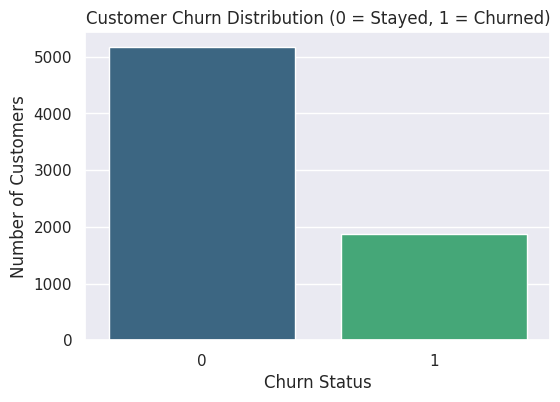

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Customer Churn Distribution (0 = Stayed, 1 = Churned)')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

print(df['Churn'].value_counts(normalize=True) * 100)

## Step 3: Train-Test Splitting
We split our features ($X$) away from our target label ($y$). Then, we separate our dataset into a Training collection (80%) to feed our algorithms, and a Testing collection (20%) to safely grade performance.

In [6]:
X = df.drop(columns=['Churn'])
y = df['Churn']

# Perform split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (5634, 19)
Testing features shape: (1409, 19)


## Step 4: Building the Preprocessing Assembly Line (`ColumnTransformer`)
We automatically segregate features based on data types.
* **Numerical features** undergo missing value imputation (`median`), followed by `StandardScaler` normalization.
* **Categorical features** undergo missing value imputation (`constant`), followed by `OneHotEncoder` string-to-numeric transformation.

In [7]:
# Identify and isolate columns dynamically by data type
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Define numerical transformation block
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Define categorical transformation block
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both pipelines into a single master preprocessor engine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline built successfully.")

Preprocessing pipeline built successfully.


## Step 5: Master Pipeline Definition & Hyperparameter Tuning via `GridSearchCV`
We establish a main execution `Pipeline` wrapper containing our `preprocessor` and a baseline classifier. We then declare a parameter search space grid containing candidate models: **Logistic Regression** and **Random Forest Classifier**, passing varying architectural settings to find the optimal combination.

In [8]:
# Initialize full processing pipeline with placeholder model
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Define parameters to test across both models
param_grid = [
    {
        'classifier': [LogisticRegression(max_iter=1000, solver='saga')],
        'classifier__C': [0.1, 1.0, 10.0]
    },
    {
        'classifier': [RandomForestClassifier(random_state=42)],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [5, 10]
    }
]

# Set up GridSearch runner with 5-fold cross-validation
grid_search = GridSearchCV(full_pipeline, param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)

print("GridSearchCV model space initialized. Executing optimization pipeline...")
grid_search.fit(X_train, y_train)

print("\n--- Tuning Complete ---")
print(f"Best Classifier Strategy Chosen: {grid_search.best_params_['classifier']}")

GridSearchCV model space initialized. Executing optimization pipeline...
Fitting 5 folds for each of 7 candidates, totalling 35 fits

--- Tuning Complete ---
Best Classifier Strategy Chosen: LogisticRegression(max_iter=1000, solver='saga')


## Step 6: Model Evaluation & Performance Validation
We test our pristine, optimized pipeline model on the untouched test subset (`X_test`). We evaluate predictions using an exact **Confusion Matrix** alongside a **Classification Report** detailing metrics like Accuracy, Precision, Recall, and F1-score.

In [9]:
best_pipeline_model = grid_search.best_estimator_
y_pred = best_pipeline_model.predict(X_test)

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Detailed Classification Report ===")
print(classification_report(y_test, y_pred))

=== Confusion Matrix ===
[[925 110]
 [165 209]]

=== Detailed Classification Report ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



## Step 7: Exporting Reusable Pipeline File
To satisfy production-readiness criteria, we dump the entire validated pipeline architecture (including our transformers and optimized weights) into a single serialized binary asset using `joblib`.

In [10]:
model_path = 'telco_churn_production_pipeline.pkl'
joblib.dump(best_pipeline_model, model_path)

print(f"Success! Model pipeline fully serialized and exported to disk at: '{model_path}'")

# Final verification sanity test
loaded_pipeline = joblib.load(model_path)
sample_prediction = loaded_pipeline.predict(X_test.iloc[[0]])
print(f"Pipeline verification check. Sample customer churn prediction outcome: {sample_prediction}")

Success! Model pipeline fully serialized and exported to disk at: 'telco_churn_production_pipeline.pkl'
Pipeline verification check. Sample customer churn prediction outcome: [0]
